In [2]:
# Cell 1: Imports & 环境配置
import scanpy as sc
import anndata
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import trange, tqdm
from sklearn.model_selection import train_test_split
import itertools
from tqdm import tqdm
import anndata as ad
import scanpy as sc

g:\C_pan_copy_dir\.conda\envs\torch_gpu_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# reproducibility
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
# Cell 3: Dataset & DataLoader
class AnnDataDataset(Dataset):
    def __init__(self, adata):
        self.X = adata.X.astype(np.float32)
        self.labels = adata.obs['cell_type'].values.astype(str)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.labels[idx]

def make_loader(adata, batch_size=64, num_workers=4):
    ds = AnnDataDataset(adata)
    return DataLoader(ds, batch_size=batch_size,
                      shuffle=True, drop_last=True,
                      num_workers=num_workers)

# Cell 4: SupConLoss & 模型定义
class SupConLoss(nn.Module):
    def __init__(self, temp=0.07):
        super().__init__()
        self.temp = temp

    def forward(self, z, labels):
        z = F.normalize(z, dim=1)
        sim = (z @ z.T) / self.temp  # [N,N]
        mask = (labels.unsqueeze(1) == labels.unsqueeze(0)).float()
        mask = mask - torch.eye(len(z), device=sim.device)
        exp_sim = torch.exp(sim) * (1 - torch.eye(len(z), device=sim.device))
        log_prob = sim - torch.log(exp_sim.sum(1, keepdim=True) + 1e-8)
        mean_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-8)
        return -mean_pos.mean()

class ModalityVAE(nn.Module):
    def __init__(self, in_dim, latent_dim=128):
        super().__init__()
        self.fc1    = nn.Linear(in_dim, 512)
        self.fc_mu  = nn.Linear(512, latent_dim)
        self.fc_lv  = nn.Linear(512, latent_dim)
        self.fc2    = nn.Linear(latent_dim, 512)
        self.fc_out = nn.Linear(512, in_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_lv(h)

    def reparam(self, mu, lv):
        std = (0.5 * lv).exp()
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        return self.fc_out(F.relu(self.fc2(z)))

    def forward(self, x):
        mu, lv = self.encode(x)
        z = self.reparam(mu, lv)
        recon = self.decode(z)
        return recon, mu, lv, z

class MultiModalVAE(nn.Module):
    def __init__(self, dims, latent_dim=128):
        super().__init__()
        self.r = ModalityVAE(dims['raman'], latent_dim)
        self.n = ModalityVAE(dims['rna'],   latent_dim)
        self.a = ModalityVAE(dims['atac'],  latent_dim)

    def forward(self, xr, xn, xa):
        out_r = self.r(xr)
        out_n = self.n(xn)
        out_a = self.a(xa)
        return out_r, out_n, out_a

def kl_div(mu, lv):
    return -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / mu.size(0)

# Cell 5: 训练/验证函数（使用 cycle 对齐 batch 数）
# 只需改下面这段 train_epoch

def train_epoch(model, opt, loaders, device, weights, writer, epoch):
    model.train()
    loss_con = SupConLoss().to(device)
    loader_r, loader_n, loader_a = loaders

    # 以最短 loader 决定步数
    steps = min(len(loader_r), len(loader_n), len(loader_a))
    total_loss = 0.

    for step, ((xr, yr), (xn, yn), (xa, ya)) in enumerate(
            tqdm(zip(loader_r, loader_n, loader_a),
                 total=steps,
                 desc=f"Train E{epoch}", leave=False)):
        xr, yr = xr.to(device), yr.to(device)
        xn, yn = xn.to(device), yn.to(device)
        xa, ya = xa.to(device), ya.to(device)

        opt.zero_grad()
        (rec_r, mu_r, lv_r, z_r), \
        (rec_n, mu_n, lv_n, z_n), \
        (rec_a, mu_a, lv_a, z_a) = model(xr, xn, xa)

        # 重建 + KL
        L_rec = (F.mse_loss(rec_r, xr)
               + F.mse_loss(rec_n, xn)
               + F.mse_loss(rec_a, xa))
        L_kl  = (kl_div(mu_r, lv_r)
               + kl_div(mu_n, lv_n)
               + kl_div(mu_a, lv_a))
        # 对比
        zs   = torch.cat([z_r, z_n, z_a], dim=0)
        labs = torch.cat([yr,   yn,   ya],   dim=0)
        L_con = loss_con(zs, labs)

        loss = weights['rec'] * L_rec \
             + weights['kl']  * L_kl  \
             + weights['con'] * L_con
        loss.backward()
        opt.step()

        total_loss += loss.item()
        gs = (epoch - 1) * steps + step
        writer.add_scalar("Train/BatchLoss", loss.item(), gs)

    avg = total_loss / steps
    writer.add_scalar("Train/EpochLoss", avg, epoch)
    return avg

def eval_epoch(model, loaders, device):
    model.eval()
    lr, ln, la = loaders
    losses = []
    with torch.no_grad():
        for (xr, _), (xn, _), (xa, _) in zip(lr, ln, la):
            xr, xn = xr.to(device), xn.to(device)
            _, _, _, z_r = model.r(xr)
            rec_n = model.n.decode(z_r)
            losses.append(F.mse_loss(rec_n, xn).item())
    return np.mean(losses)


In [17]:
# Cell 7
# 加载数据
adata_r = ad.read_h5ad("./data/raman_B.h5ad")
adata_n = ad.read_h5ad("./data/abc_B_lineage_processed.h5ad")
adata_a = ad.read_h5ad('./data/atac_data/BMMC_refined_bcell_subset.h5ad')
print(adata_r)
print(adata_n)
print(adata_a)

AnnData object with n_obs × n_vars = 1415 × 432
    obs: 'cell_type'
AnnData object with n_obs × n_vars = 938 × 19813
    obs: 'celltype', 'UMI_number', 'gene_number', 'individual', 'tissue', 'population', 'cluster', 'redefined_cluster', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm:

In [21]:
adata_n.var["highly_variable"].sum()

2000

In [19]:
adata_r.obs["cell_type"].unique()

['HSC', 'Pro B', 'Pre B', 'Naive B']
Categories (4, object): ['HSC', 'Naive B', 'Pre B', 'Pro B']

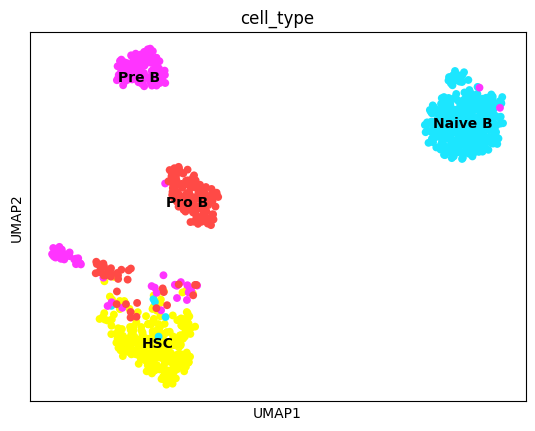

In [12]:
sc.pl.umap(adata_n,color=["cell_type"],palette=sc.pl.palettes.default_102,legend_loc="on data")

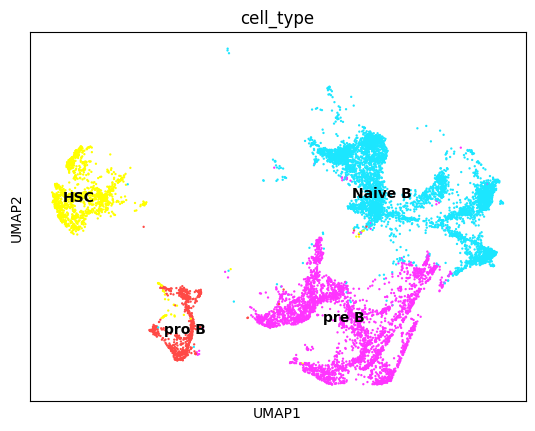

In [6]:
adata_a.obs["cell_type"] = adata_a.obs["cell_type_refined"]
sc.pl.umap(adata_a,color=["cell_type"],palette=sc.pl.palettes.default_102,legend_loc="on data")

In [7]:
# zero_center=True（均值为0），max_value=None（不截断）
sc.pp.scale(adata_r, zero_center=True, max_value=None)
# 结果放在 adata_r.X

# 假如 high_var 已经计算好了，直接子集
hv_mask = adata_n.var['highly_variable']
adata_n = adata_n[:, hv_mask].copy()
# adata_n.X 已是 log1p+scale 后的结果

# 3. scATAC 数据
# 直接 scale（注意会把 sparse 转成 dense，若内存不足再改回手动）
sc.pp.scale(adata_a, zero_center=True, max_value=None)
# 结果放在 adata_a.X


In [8]:
# 划分索引（分层抽样）
idx_r = np.arange(adata_r.n_obs)
idx_n = np.arange(adata_n.n_obs)
idx_a = np.arange(adata_a.n_obs)
train_r, test_r = train_test_split(idx_r, test_size=0.2,
                                    stratify=adata_r.obs['cell_type'], random_state=42)
train_n, test_n = train_test_split(idx_n, test_size=0.2,
                                    stratify=adata_n.obs['cell_type'], random_state=42)
train_a, test_a = train_test_split(idx_a, test_size=0.2,
                                    stratify=adata_a.obs['cell_type'], random_state=42)

tr_r, te_r = adata_r[train_r], adata_r[test_r]
tr_n, te_n = adata_n[train_n], adata_n[test_n]
tr_a, te_a = adata_a[train_a], adata_a[test_a]

loader_r_train = make_loader(tr_r)
loader_n_train = make_loader(tr_n)
loader_a_train = make_loader(tr_a)
loader_r_test  = make_loader(te_r, batch_size=64, num_workers=2)
loader_n_test  = make_loader(te_n, batch_size=64, num_workers=2)
loader_a_test  = make_loader(te_a, batch_size=64, num_workers=2)

In [ ]:
# Cell 6: 主循环

dims = {
    'raman': tr_r.X.shape[1],
    'rna':   tr_n.X.shape[1],
    'atac':  tr_a.X.shape[1],
}
model = MultiModalVAE(dims, latent_dim=128).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
writer = SummaryWriter("./logs_shared_latent")

weights = {'rec':1.0, 'kl':0.1, 'con':0.5}
epochs = 50

for epoch in trange(1, epochs+1, desc="Overall Training"):
    tr_loss = train_epoch(model, opt,
                         (loader_r_train, loader_n_train, loader_a_train),
                         device, weights, writer, epoch)
    val_mse = eval_epoch(model,
                         (loader_r_test, loader_n_test, loader_a_test),
                         device)
    writer.add_scalar("Test/Raman2RNA_MSE", val_mse, epoch)
    print(f"[Epoch {epoch:02d}] TrainLoss={tr_loss:.4f} | Raman→RNA MSE={val_mse:.4f}")

writer.close()

Overall Training:   0%|          | 0/50 [00:00<?, ?it/s]

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device =", device)


Using device = cuda


In [10]:
# Cell 1: Imports & 配置
import scanpy as sc
import anndata
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import trange, tqdm
from sklearn.model_selection import train_test_split

# 确保可复现
np.random.seed(42)
torch.manual_seed(42)

# 自动选 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
# Cell 2: 数据加载 & 预处理
# 1) Raman
adata_r = sc.read_h5ad("./data/raman_B.h5ad")
adata_r.raw = adata_r.copy()
sc.pp.scale(adata_r, zero_center=True, max_value=None)  # Z-score

# 2) scRNA（选 2000 HVG）
adata_n = sc.read_h5ad("./data/abc_B_lineage_processed.h5ad")
hv_mask = adata_n.var["highly_variable"].values
adata_n = adata_n[:, hv_mask].copy()
# sc.pp.scale(adata_n, zero_center=True, max_value=None)  
# （如果还想再 scale，可加上；这里假设已做过 log1p+scale）

print(f"Raman dims: {adata_r.X.shape}, scRNA dims: {adata_n.X.shape}")
# Cell 3: Dataset & DataLoader
# Cell 3: Dataset & DataLoader（更新版，标签预先 factorize）
import pandas as pd

class TwoModalityDataset(Dataset):
    def __init__(self, adata_r, adata_n, idx_r, idx_n):
        # 特征数组
        self.Xr = adata_r.X[idx_r].astype(np.float32)
        self.Xn = adata_n.X[idx_n].astype(np.float32)
        # 把所有 cell_type 字符串映射成整数 codes
        labels_series = adata_r.obs["cell_type"].astype(str)
        codes, uniques = pd.factorize(labels_series)
        # 只保留训练/测试里对应的那些样本的 code
        self.labels = codes[idx_r].astype(np.int64)  # numpy array of ints

    def __len__(self):
        return min(len(self.Xr), len(self.Xn))

    def __getitem__(self, i):
        # 这里返回的 labels[i] 已经是一个 numpy.int64
        return self.Xr[i], self.Xn[i], self.labels[i]

def make_loaders(adata_r, adata_n, batch_size=64):
    idxs_r = np.arange(adata_r.n_obs)
    idxs_n = np.arange(adata_n.n_obs)
    tr_r, te_r = train_test_split(
        idxs_r, test_size=0.2,
        stratify=adata_r.obs["cell_type"], random_state=0
    )
    tr_n, te_n = train_test_split(
        idxs_n, test_size=0.2,
        stratify=adata_n.obs["cell_type"], random_state=0
    )

    train_ds = TwoModalityDataset(adata_r, adata_n, tr_r, tr_n)
    test_ds  = TwoModalityDataset(adata_r, adata_n, te_r, te_n)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size,
        shuffle=True, drop_last=True
    )
    test_loader  = DataLoader(
        test_ds, batch_size=batch_size,
        shuffle=False
    )
    return train_loader, test_loader

loader_train, loader_test = make_loaders(adata_r, adata_n, batch_size=64)

# Cell 4: Supervised Contrastive & 双分支 VAE 定义
class SupConLoss(nn.Module):
    def __init__(self, temp=0.07):
        super().__init__()
        self.temp = temp

    def forward(self, z, labels):
        # z: [B, D], labels: [B]
        z = F.normalize(z, dim=1)
        sim = z @ z.T / self.temp
        mask = (labels.unsqueeze(1) == labels.unsqueeze(0)).float()
        mask.fill_diagonal_(0)
        exp_sim = torch.exp(sim) * (1 - torch.eye(len(z), device=z.device))
        log_prob = sim - torch.log(exp_sim.sum(1, keepdim=True) + 1e-8)
        mean_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-8)
        return -mean_pos.mean()

class ModalityVAE(nn.Module):
    def __init__(self, in_dim, latent_dim=64):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_lv = nn.Linear(256, latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, in_dim)
        )

    def forward(self, x):
        h = self.enc(x)
        mu = self.fc_mu(h)
        lv = self.fc_lv(h)
        std = (0.5*lv).exp()
        z = mu + std * torch.randn_like(std)
        return self.dec(z), mu, lv, z

class TwoModalVAE(nn.Module):
    def __init__(self, dim_r, dim_n, latent_dim=64):
        super().__init__()
        self.v_r = ModalityVAE(dim_r, latent_dim)
        self.v_n = ModalityVAE(dim_n, latent_dim)

    def forward(self, xr, xn):
        out_r = self.v_r(xr)
        out_n = self.v_n(xn)
        return out_r, out_n

def kl_div(mu, lv):
    return -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / mu.size(0)
# Cell 5: 训练 & 验证 函数
def train_epoch(model, opt, loader, device, weights, writer, epoch):
    model.train()
    loss_con = SupConLoss().to(device)
    total = 0

    for step, (xr, xn, labels) in enumerate(tqdm(loader, desc=f"Train E{epoch}", leave=False)):
        xr = xr.to(device); xn = xn.to(device)
        # 把 int 或 list of ints 转成 LongTensor
        labels = torch.tensor(labels, dtype=torch.long, device=device)

        opt.zero_grad()
        (rec_r, mu_r, lv_r, z_r), (rec_n, mu_n, lv_n, z_n) = model(xr, xn)

        L_rec = F.mse_loss(rec_r, xr) + F.mse_loss(rec_n, xn)
        L_kl  = kl_div(mu_r, lv_r) + kl_div(mu_n, lv_n)

        # 对比，将两个 modality 的 z 串起来，标签也复制一次
        zs   = torch.cat([z_r, z_n], dim=0)
        labs = torch.cat([labels, labels], dim=0)
        L_con = loss_con(zs, labs)

        loss = weights['rec'] * L_rec + weights['kl'] * L_kl + weights['con'] * L_con
        loss.backward(); opt.step()

        total += loss.item()
        gs = (epoch-1) * len(loader) + step
        writer.add_scalar("Train/BatchLoss", loss.item(), gs)

    avg = total / len(loader)
    writer.add_scalar("Train/EpochLoss", avg, epoch)
    return avg


def eval_epoch(model, loader, device):
    model.eval()
    tot = 0
    with torch.no_grad():
        for xr, xn, _ in loader:
            xr = xr.to(device); xn = xn.to(device)
            ( _ , mu_r, lv_r, z_r), (_ , mu_n, lv_n, z_n) = model(xr, xn)
            # 用 Raman latent 重建 scRNA
            rec_n = model.v_n.dec(z_r)
            tot += F.mse_loss(rec_n, xn).item()
    return tot / len(loader)


Using device: cuda
Raman dims: (1415, 432), scRNA dims: (938, 2000)


In [11]:
# Cell 6: 主循环（简化测试版）
from tqdm.auto import trange
import torch

# 参数
epochs = 2
lr = 1e-3

# 确认 loader 长度
print("Train batches:", len(loader_train), "  Test batches:", len(loader_test))

# 模型、优化器、TensorBoard
dim_r, dim_n = adata_r.X.shape[1], adata_n.X.shape[1]
model = TwoModalVAE(dim_r, dim_n, latent_dim=64).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=lr)
writer = SummaryWriter("./logs_2mod_shared_test")

# 超参权重
weights = {'rec':1.0, 'kl':0.1, 'con':0.5}

for epoch in trange(1, epochs+1, desc="Overall Training"):
    print(f"\n>>> Starting epoch {epoch}")
    # 训练
    tr_loss = train_epoch(model, opt, loader_train, device, weights, writer, epoch)
    print(f"  Epoch {epoch} Train Loss: {tr_loss:.4f}")
    # 验证
    val_mse = eval_epoch(model, loader_test, device)
    print(f"  Epoch {epoch} Val   MSE:   {val_mse:.4f}")
    # 记录 TensorBoard
    writer.add_scalar("Val/Raman2RNA_MSE", val_mse, epoch)
    writer.flush()    # 强制写入

writer.close()
print("Done training test run.")


Train batches: 11   Test batches: 3


Overall Training:   0%|          | 0/2 [00:00<?, ?it/s]


>>> Starting epoch 1


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13096\3503898455.py:143: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.long, device=device)
Overall Training:  50%|█████     | 1/2 [00:00<00:00,  1.21it/s]

  Epoch 1 Train Loss: 5.6360
  Epoch 1 Val   MSE:   1.0000

>>> Starting epoch 2


Overall Training: 100%|██████████| 2/2 [00:01<00:00,  2.00it/s]

  Epoch 2 Train Loss: 5.5701
  Epoch 2 Val   MSE:   0.9926
Done training test run.


In [4]:
# Cell 1: Imports & 配置
import scanpy as sc
import anndata
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import trange, tqdm
from sklearn.model_selection import train_test_split

# 可复现
np.random.seed(42)
torch.manual_seed(42)

# 选设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
# Cell 2: 数据加载 & 预处理
# 1) Raman
adata_r = sc.read_h5ad("./data/raman_B.h5ad")
adata_r.raw = adata_r.copy()
sc.pp.scale(adata_r, zero_center=True, max_value=None)

# 2) scRNA（HVG 子集）
adata_n = sc.read_h5ad("./data/abc_B_lineage_processed.h5ad")
hv_mask = adata_n.var["highly_variable"].values
adata_n = adata_n[:, hv_mask].copy()

# 3) scATAC
adata_a = sc.read_h5ad("./data/atac_data/BMMC_refined_bcell_subset.h5ad")
sc.pp.scale(adata_a, zero_center=True, max_value=None)

print(f"Shapes → Raman: {adata_r.X.shape}, scRNA: {adata_n.X.shape}, scATAC: {adata_a.X.shape}")
# Cell 3: Dataset & DataLoader（三模态）
# Cell 3: Dataset & DataLoader（三模态，修复 stratify 错误）
class ThreeModalityDataset(Dataset):
    def __init__(self, adata_r, adata_n, adata_a, idx_r, idx_n, idx_a):
        self.Xr = adata_r.X[idx_r].astype(np.float32)
        self.Xn = adata_n.X[idx_n].astype(np.float32)
        self.Xa = adata_a.X[idx_a].astype(np.float32)
        labels = adata_r.obs["cell_type"].astype(str)
        codes, _ = pd.factorize(labels)
        self.labels = codes[idx_r].astype(np.int64)

    def __len__(self):
        return min(self.Xr.shape[0], self.Xn.shape[0], self.Xa.shape[0])

    def __getitem__(self, i):
        return self.Xr[i], self.Xn[i], self.Xa[i], self.labels[i]

def make_loaders_3mod(adata_r, adata_n, adata_a, batch_size=64):
    idxs_r = np.arange(adata_r.n_obs)
    idxs_n = np.arange(adata_n.n_obs)
    idxs_a = np.arange(adata_a.n_obs)

    # scRaman & scRNA 分层抽样
    tr_r, te_r = train_test_split(
        idxs_r, test_size=0.2,
        stratify=adata_r.obs["cell_type"], random_state=0
    )
    tr_n, te_n = train_test_split(
        idxs_n, test_size=0.2,
        stratify=adata_n.obs["cell_type"], random_state=0
    )
    # scATAC 随机拆分（不 stratify）
    tr_a, te_a = train_test_split(
        idxs_a, test_size=0.2,
        shuffle=True, random_state=0
    )

    train_ds = ThreeModalityDataset(adata_r, adata_n, adata_a, tr_r, tr_n, tr_a)
    test_ds  = ThreeModalityDataset(adata_r, adata_n, adata_a, te_r, te_n, te_a)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size,
        shuffle=True, drop_last=True, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size,
        shuffle=False, pin_memory=True
    )
    return train_loader, test_loader

loader_train, loader_test = make_loaders_3mod(
    adata_r, adata_n, adata_a, batch_size=64
)
print("Train batches:", len(loader_train), "Test batches:", len(loader_test))

# Cell 4: SupConLoss & 三模态 VAE 定义
class SupConLoss(nn.Module):
    def __init__(self, temp=0.07):
        super().__init__()
        self.temp = temp

    def forward(self, z, labels):
        z = F.normalize(z, dim=1)
        sim = (z @ z.T) / self.temp
        mask = (labels.unsqueeze(1) == labels.unsqueeze(0)).float()
        mask.fill_diagonal_(0)
        exp_sim = torch.exp(sim) * (1 - torch.eye(len(z), device=z.device))
        log_prob = sim - torch.log(exp_sim.sum(1, keepdim=True) + 1e-8)
        mean_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-8)
        return -mean_pos.mean()

class ModalityVAE(nn.Module):
    def __init__(self, in_dim, latent_dim=64):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU()
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_lv = nn.Linear(256, latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, in_dim)
        )

    def forward(self, x):
        h = self.enc(x)
        mu = self.fc_mu(h)
        lv = self.fc_lv(h)
        std = (0.5 * lv).exp()
        z = mu + std * torch.randn_like(std)
        recon = self.dec(z)
        return recon, mu, lv, z

    def decode(self, z):
        return self.dec(z)

class MultiModalVAE(nn.Module):
    def __init__(self, dims, latent_dim=64):
        super().__init__()
        self.v_r = ModalityVAE(dims['raman'], latent_dim)
        self.v_n = ModalityVAE(dims['rna'],   latent_dim)
        self.v_a = ModalityVAE(dims['atac'],  latent_dim)

    def forward(self, xr, xn, xa):
        out_r = self.v_r(xr)
        out_n = self.v_n(xn)
        out_a = self.v_a(xa)
        return out_r, out_n, out_a

def kl_div(mu, lv):
    return -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / mu.size(0)
# Cell 5: 训练 & 验证 函数（三模态）
# ----------------------------
# Cell 5’: 改进后的 训练 & 验证 函数
# ----------------------------
def train_epoch_3mod(model, opt, loader, device, weights, writer, epoch):
    model.train()
    loss_con = SupConLoss().to(device)
    total = 0
    steps = len(loader)

    for step, (xr, xn, xa, labels) in enumerate(tqdm(loader, desc=f"Train E{epoch}", leave=False)):
        xr = xr.to(device); xn = xn.to(device); xa = xa.to(device)
        labels = torch.tensor(labels, dtype=torch.long, device=device)

        opt.zero_grad()
        # forward
        (rec_r, mu_r, lv_r, z_r), \
        (rec_n, mu_n, lv_n, z_n), \
        (rec_a, mu_a, lv_a, z_a) = model(xr, xn, xa)

        # Reconstruction loss
        L_rec = (
            F.mse_loss(rec_r, xr)
          + F.mse_loss(rec_n, xn)
          + F.mse_loss(rec_a, xa)
        )
        # KL divergence
        L_kl = (
            kl_div(mu_r, lv_r)
          + kl_div(mu_n, lv_n)
          + kl_div(mu_a, lv_a)
        )
        # Contrastive loss
        zs   = torch.cat([z_r, z_n, z_a], dim=0)
        labs = torch.cat([labels, labels, labels], dim=0)
        L_con = loss_con(zs, labs)

        # 总 loss
        loss = (
            weights['rec'] * L_rec
          + weights['kl']  * L_kl
          + weights['con'] * L_con
        )
        loss.backward()
        opt.step()

        total += loss.item()
        global_step = (epoch-1) * steps + step

        # 写入 TensorBoard
        writer.add_scalar('Loss/Total',     loss.item(), global_step)
        writer.add_scalar('Loss/Reconstruction', L_rec.item(), global_step)
        writer.add_scalar('Loss/KL',         L_kl.item(), global_step)
        writer.add_scalar('Loss/Contrastive',L_con.item(), global_step)

    avg = total / steps
    writer.add_scalar('Loss/EpochAvg', avg, epoch)
    return avg

def eval_epoch_3mod(model, loader, device):
    model.eval()
    tot_rn = tot_ra = 0
    with torch.no_grad():
        for xr, xn, xa, _ in loader:
            xr = xr.to(device); xn = xn.to(device); xa = xa.to(device)
            (_,_,_, z_r), *_ = model(xr, xn, xa)
            rec_n = model.v_n.decode(z_r)
            rec_a = model.v_a.decode(z_r)
            tot_rn += F.mse_loss(rec_n, xn).item()
            tot_ra += F.mse_loss(rec_a, xa).item()
    return tot_rn/len(loader), tot_ra/len(loader)


Using device: cuda
Shapes → Raman: (1415, 432), scRNA: (938, 2000), scATAC: (10738, 19039)
Train batches: 11 Test batches: 3


In [5]:
# Cell 6: 主循环（三模态共享 latent）
dims = {
    'raman': adata_r.X.shape[1],
    'rna':   adata_n.X.shape[1],
    'atac':  adata_a.X.shape[1],
}
model = MultiModalVAE(dims, latent_dim=64).to(device)
writer = SummaryWriter("./logs_3mod_shared")

# ----------------------------
# Cell 6’: 改进后的主循环（示例超参调整）
# ----------------------------
# 建议：减小 KL 和 Contrastive 权重、降低学习率
weights = {'rec':1.0, 'kl':0.01, 'con':0.1}
lr = 5e-4    # 从 1e-3 调低到 5e-4
epochs = 50  # 可以适当增加

opt = torch.optim.Adam(model.parameters(), lr=lr)

for epoch in trange(1, epochs+1, desc="Overall Training"):
    tr_loss = train_epoch_3mod(
        model, opt, loader_train, device, weights, writer, epoch
    )
    val_rn, val_ra = eval_epoch_3mod(model, loader_test, device)
    writer.add_scalar("Val/Raman2RNA_MSE", val_rn, epoch)
    writer.add_scalar("Val/Raman2ATAC_MSE", val_ra, epoch)
    print(
        f"[{epoch:02d}] TrainLoss={tr_loss:.4f} "
        f"| RN MSE={val_rn:.4f} | AT MSE={val_ra:.4f}"
    )

writer.close()


Overall Training:   0%|          | 0/50 [00:00<?, ?it/s]C:\Users\Administrator\AppData\Local\Temp\ipykernel_31284\2483780927.py:160: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, dtype=torch.long, device=device)
Overall Training:   2%|▏         | 1/50 [00:00<00:18,  2.60it/s]

[01] TrainLoss=3.8962 | RN MSE=1.0003 | AT MSE=1.0148


Overall Training:   4%|▍         | 2/50 [00:00<00:14,  3.34it/s]

[02] TrainLoss=3.9098 | RN MSE=0.9963 | AT MSE=1.0105


Overall Training:   6%|▌         | 3/50 [00:00<00:12,  3.70it/s]

...

[48] TrainLoss=3.1193 | RN MSE=0.9905 | AT MSE=0.9938


Overall Training:  98%|█████████▊| 49/50 [00:12<00:00,  3.98it/s]

[49] TrainLoss=3.1094 | RN MSE=0.9939 | AT MSE=0.9958


Overall Training: 100%|██████████| 50/50 [00:13<00:00,  3.79it/s]

[50] TrainLoss=3.1110 | RN MSE=0.9896 | AT MSE=0.9932


In [2]:
# Two-Stage Training for Three-Modality Shared-Latent VAE
# Copy this entire script into a .py file or Jupyter Notebook and run.

# ----------------------------
# Cell 1: Install dependencies (run once in notebook or terminal)
# ----------------------------
# !pip install scanpy torch tqdm tensorboard sklearn pandas anndata

# ----------------------------
# Cell 2: Imports & Configuration
# ----------------------------
import os
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import trange, tqdm
from sklearn.model_selection import train_test_split

# reproducibility
np.random.seed(42)
torch.manual_seed(42)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------
# Cell 3: Data Loading & Preprocessing
# ----------------------------
# Paths to your .h5ad files
path_r = "./data/raman_B.h5ad"
path_n = "./data/abc_B_lineage_processed.h5ad"
path_a = "./data/atac_data/BMMC_refined_bcell_subset.h5ad"

# 1) Raman
adata_r = sc.read_h5ad(path_r)
adata_r.raw = adata_r.copy()
sc.pp.scale(adata_r, zero_center=True, max_value=None)

# 2) scRNA (HVG subset)
adata_n = sc.read_h5ad(path_n)
hv_mask = adata_n.var["highly_variable"].values
adata_n = adata_n[:, hv_mask].copy()
#  Optionally: sc.pp.scale(adata_n, zero_center=True, max_value=None)

# 3) scATAC
adata_a = sc.read_h5ad(path_a)
sc.pp.scale(adata_a, zero_center=True, max_value=None)

print(f"Shapes → Raman: {adata_r.X.shape}, scRNA: {adata_n.X.shape}, scATAC: {adata_a.X.shape}")

# ----------------------------
# Cell 4: Dataset & DataLoader Definitions
# ----------------------------
class AnnDataDataset(Dataset):
    def __init__(self, adata):
        self.X = adata.X.astype(np.float32)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx]

def make_single_loader(adata, batch_size=64):
    ds = AnnDataDataset(adata)
    return DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True, pin_memory=True)

# Pretrain loaders for each modality
loader_r_pre, _ = make_single_loader(adata_r, batch_size=64), None
loader_n_pre, _ = make_single_loader(adata_n, batch_size=64), None
loader_a_pre, _ = make_single_loader(adata_a, batch_size=64), None

# Three-modality Dataset for fine-tuning
class ThreeModalityDataset(Dataset):
    def __init__(self, ad_r, ad_n, ad_a, idx_r, idx_n, idx_a):
        self.Xr = ad_r.X[idx_r].astype(np.float32)
        self.Xn = ad_n.X[idx_n].astype(np.float32)
        self.Xa = ad_a.X[idx_a].astype(np.float32)
        labels = ad_r.obs["cell_type"].astype(str)
        codes, _ = pd.factorize(labels)
        self.labels = codes[idx_r].astype(np.int64)
    def __len__(self):
        return min(self.Xr.shape[0], self.Xn.shape[0], self.Xa.shape[0])
    def __getitem__(self, i):
        return self.Xr[i], self.Xn[i], self.Xa[i], self.labels[i]

def make_three_loader(ad_r, ad_n, ad_a, batch_size=64):
    idx_r = np.arange(ad_r.n_obs)
    idx_n = np.arange(ad_n.n_obs)
    idx_a = np.arange(ad_a.n_obs)
    tr_r, te_r = train_test_split(idx_r, test_size=0.2,
                                   stratify=ad_r.obs["cell_type"], random_state=0)
    tr_n, te_n = train_test_split(idx_n, test_size=0.2,
                                   stratify=ad_n.obs["cell_type"], random_state=0)
    tr_a, te_a = train_test_split(idx_a, test_size=0.2,
                                   shuffle=True, random_state=0)
    train_ds = ThreeModalityDataset(ad_r, ad_n, ad_a, tr_r, tr_n, tr_a)
    test_ds  = ThreeModalityDataset(ad_r, ad_n, ad_a, te_r, te_n, te_a)
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True, drop_last=True, pin_memory=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size,
                              shuffle=False, pin_memory=True)
    return train_loader, test_loader

loader_train, loader_test = make_three_loader(adata_r, adata_n, adata_a, batch_size=64)
print("Three-modality → Train batches:", len(loader_train), "Test batches:", len(loader_test))

# ----------------------------
# Cell 5: VAE Model Definitions
# ----------------------------
class ModalityVAE(nn.Module):
    def __init__(self, in_dim, latent_dim=64):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(in_dim, 256), nn.ReLU())
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_lv = nn.Linear(256, latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, in_dim)
        )
    def forward(self, x):
        h = self.enc(x)
        mu = self.fc_mu(h)
        lv = self.fc_lv(h)
        std = (0.5 * lv).exp()
        z = mu + std * torch.randn_like(std)
        recon = self.dec(z)
        return recon, mu, lv, z
    def decode(self, z):
        return self.dec(z)

class TwoModalVAE(nn.Module):
    # used for pretrain
    def __init__(self, in_dim, latent_dim=64):
        super().__init__()
        self.v = ModalityVAE(in_dim, latent_dim)
    def forward(self, x):
        return self.v(x)

class MultiModalVAE(nn.Module):
    def __init__(self, dims, latent_dim=64):
        super().__init__()
        self.v_r = ModalityVAE(dims['raman'], latent_dim)
        self.v_n = ModalityVAE(dims['rna'],   latent_dim)
        self.v_a = ModalityVAE(dims['atac'],  latent_dim)
    def forward(self, xr, xn, xa):
        return self.v_r(xr), self.v_n(xn), self.v_a(xa)

def kl_div(mu, lv):
    return -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / mu.size(0)

# ----------------------------
# Cell 6: Pre-train Single-Modality VAEs
# ----------------------------
def pretrain_vae(model, loader, device, lr=1e-3, epochs=20, logdir="pretrain"):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    writer = SummaryWriter(f"./logs_{logdir}")
    for epoch in range(1, epochs+1):
        model.train()
        total = 0
        for x in tqdm(loader, desc=f"{logdir} E{epoch}", leave=False):
            x = x.to(device)
            opt.zero_grad()
            recon, mu, lv, _ = model(x)
            L_rec = F.mse_loss(recon, x)
            L_kl  = kl_div(mu, lv)
            loss = L_rec + 0.1 * L_kl
            loss.backward(); opt.step()
            total += loss.item()
        avg = total / len(loader)
        writer.add_scalar("Loss/Pretrain", avg, epoch)
        print(f"[{logdir} Pretrain E{epoch:02d}] Loss={avg:.4f}")
    writer.close()
    return model.state_dict()

# instantiate for pretrain
vae_r = TwoModalVAE(adata_r.X.shape[1], latent_dim=64)
vae_n = TwoModalVAE(adata_n.X.shape[1], latent_dim=64)
vae_a = TwoModalVAE(adata_a.X.shape[1], latent_dim=64)

# pretrain and save
sd_r = pretrain_vae(vae_r, loader_r_pre, device, epochs=20, logdir="Raman")
sd_n = pretrain_vae(vae_n, loader_n_pre, device, epochs=20, logdir="RNA")
sd_a = pretrain_vae(vae_a, loader_a_pre, device, epochs=20, logdir="ATAC")

os.makedirs("./checkpoints", exist_ok=True)
torch.save(sd_r, "./checkpoints/vae_r_pretrain.pth")
torch.save(sd_n, "./checkpoints/vae_n_pretrain.pth")
torch.save(sd_a, "./checkpoints/vae_a_pretrain.pth")

# ----------------------------
# Cell 7: Fine-Tune MultiModalVAE with Contrastive Loss
# ----------------------------
# load pretrain weights
# ----------------------------
# Cell 7: 加载预训练权重（修正版）
# ----------------------------
# 初始化 MultiModalVAE
dims = {
    'raman': adata_r.X.shape[1],
    'rna':   adata_n.X.shape[1],
    'atac':  adata_a.X.shape[1],
}
mmvae = MultiModalVAE(dims, latent_dim=64).to(device)

# 读入预训练的 state_dict
sd_r = torch.load("./checkpoints/vae_r_pretrain.pth")
sd_n = torch.load("./checkpoints/vae_n_pretrain.pth")
sd_a = torch.load("./checkpoints/vae_a_pretrain.pth")

# 将 'v.' 前缀去掉，然后加载到对应子模块
def load_branch(branch_module, pretrained_sd):
    # pretrained_sd 的 key 形如 'v.enc.0.weight'，去掉 'v.'
    sub_sd = { k[len("v."):]: v for k, v in pretrained_sd.items() if k.startswith("v.") }
    branch_module.load_state_dict(sub_sd)

load_branch(mmvae.v_r, sd_r)
load_branch(mmvae.v_n, sd_n)
load_branch(mmvae.v_a, sd_a)

print("✅ Pretrained weights loaded into mmvae.v_r, mmvae.v_n, mmvae.v_a")


# SupConLoss for fine-tune
class SupConLoss(nn.Module):
    def __init__(self, temp=0.07):
        super().__init__()
        self.temp = temp
    def forward(self, z, labels):
        z = F.normalize(z, dim=1)
        sim = (z @ z.T) / self.temp
        mask = (labels.unsqueeze(1) == labels.unsqueeze(0)).float()
        mask.fill_diagonal_(0)
        exp_sim = torch.exp(sim) * (1 - torch.eye(len(z), device=z.device))
        log_prob = sim - torch.log(exp_sim.sum(1, keepdim=True) + 1e-8)
        mean_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-8)
        return -mean_pos.mean()

def train_epoch_3mod(model, opt, loader, device, weights, writer, epoch):
    model.train()
    loss_con = SupConLoss().to(device)
    total = 0
    steps = len(loader)
    for step, (xr, xn, xa, labels) in enumerate(tqdm(loader, desc=f"Fine E{epoch}", leave=False)):
        xr, xn, xa = xr.to(device), xn.to(device), xa.to(device)
        labels = torch.tensor(labels, dtype=torch.long, device=device)
        opt.zero_grad()
        out_r = model.v_r(xr)
        out_n = model.v_n(xn)
        out_a = model.v_a(xa)
        rec_r, mu_r, lv_r, z_r = out_r
        rec_n, mu_n, lv_n, z_n = out_n
        rec_a, mu_a, lv_a, z_a = out_a
        L_rec = F.mse_loss(rec_r, xr) + F.mse_loss(rec_n, xn) + F.mse_loss(rec_a, xa)
        L_kl  = kl_div(mu_r, lv_r) + kl_div(mu_n, lv_n) + kl_div(mu_a, lv_a)
        zs = torch.cat([z_r, z_n, z_a], dim=0)
        labs = torch.cat([labels, labels, labels], dim=0)
        L_con = loss_con(zs, labs)
        loss = weights['rec']*L_rec + weights['kl']*L_kl + weights['con']*L_con
        loss.backward(); opt.step()
        total += loss.item()
        gs = (epoch-1)*steps + step
        writer.add_scalar("Loss/Total", loss.item(), gs)
    avg = total/steps
    writer.add_scalar("Loss/EpochAvg", avg, epoch)
    return avg

def eval_epoch_3mod(model, loader, device):
    model.eval()
    tot_rn = tot_ra = 0
    with torch.no_grad():
        for xr, xn, xa, _ in loader:
            xr, xn, xa = xr.to(device), xn.to(device), xa.to(device)
            rec_r, mu_r, lv_r, z_r = model.v_r(xr)
            rec_n = model.v_n.decode(z_r)
            rec_a = model.v_a.decode(z_r)
            tot_rn += F.mse_loss(rec_n, xn).item()
            tot_ra += F.mse_loss(rec_a, xa).item()
    return tot_rn/len(loader), tot_ra/len(loader)

# fine-tune
opt = torch.optim.Adam(mmvae.parameters(), lr=5e-4)
writer = SummaryWriter("./logs_finetune_3mod")
weights = {'rec':1.0, 'kl':0.01, 'con':0.1}
for epoch in trange(1, 31, desc="Fine-tune"):
    tr_loss = train_epoch_3mod(mmvae, opt, loader_train, device, weights, writer, epoch)
    val_rn, val_ra = eval_epoch_3mod(mmvae, loader_test, device)
    writer.add_scalar("Val/Raman2RNA", val_rn, epoch)
    writer.add_scalar("Val/Raman2ATAC", val_ra, epoch)
    print(f"[Fine E{epoch:02d}] TrainLoss={tr_loss:.4f} | RN MSE={val_rn:.4f} AT MSE={val_ra:.4f}")
writer.close()


Using device: cuda
Shapes → Raman: (1415, 432), scRNA: (938, 2000), scATAC: (10738, 19039)
Three-modality → Train batches: 11 Test batches: 3


[Raman Pretrain E01] Loss=1.1155


[Raman Pretrain E02] Loss=1.0430


[Raman Pretrain E03] Loss=1.0270


[Raman Pretrain E04] Loss=1.0052


...

[Fine E28] TrainLoss=3.1546 | RN MSE=0.9755 AT MSE=0.9874


Fine-tune:  97%|█████████▋| 29/30 [00:07<00:00,  3.91it/s]

[Fine E29] TrainLoss=3.1224 | RN MSE=0.9762 AT MSE=0.9884


Fine-tune: 100%|██████████| 30/30 [00:08<00:00,  3.72it/s]

[Fine E30] TrainLoss=3.1391 | RN MSE=0.9758 AT MSE=0.9898


In [2]:
# Cell 1: Imports & 配置
import scanpy as sc
import anndata
import numpy as np
from scipy import sparse
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import trange, tqdm
from torch.utils.tensorboard import SummaryWriter

# 固定随机种子、选择设备
np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Cell 2: 加载 ATAC 数据 & HV 筛选 & Scale
adata = sc.read_h5ad("./data/atac_data/BMMC_refined_bcell_subset.h5ad")

# 选 2000 个高变峰值（flavor 可选 'seurat_v3'、'seurat' 等）
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat', subset=True)
print("After HV selection:", adata.X.shape)

# Z-score 标准化
sc.pp.scale(adata, zero_center=True, max_value=None)
print("After scaling:", adata.X.shape)

# Cell 3: Dataset & DataLoader
class ATACDataset(Dataset):
    def __init__(self, adata):
        X = adata.X
        if sparse.issparse(X):
            X = X.toarray()
        self.X = X.astype(np.float32)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx]

batch_size = 64
dataset = ATACDataset(adata)
loader  = DataLoader(dataset, batch_size=batch_size,
                     shuffle=True, drop_last=True,
                     num_workers=0, pin_memory=True)

# Cell 4: VAE 定义
class StandardEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),  nn.BatchNorm1d(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),  nn.BatchNorm1d(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),  nn.BatchNorm1d(hidden_dim), nn.ReLU(),
        )
        self.to_mu  = nn.Linear(hidden_dim, latent_dim)
        self.to_logv= nn.Linear(hidden_dim, latent_dim)
    def forward(self, x):
        h = self.net(x)
        return self.to_mu(h), self.to_logv(h)

class StandardDecoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),  nn.BatchNorm1d(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),  nn.BatchNorm1d(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),  nn.BatchNorm1d(hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )
    def forward(self, z):
        return self.net(z)

class ATACVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=64, hidden_dim=512):
        super().__init__()
        self.encoder = StandardEncoder(input_dim, latent_dim, hidden_dim)
        self.decoder = StandardDecoder(input_dim, latent_dim, hidden_dim)
    def reparam(self, mu, logv):
        std = (0.5*logv).exp()
        return mu + std * torch.randn_like(std)
    def forward(self, x):
        mu, logv = self.encoder(x)
        z = self.reparam(mu, logv)
        recon = self.decoder(z)
        return recon, mu, logv

def kl_div(mu, logv):
    return -0.5 * torch.sum(1 + logv - mu.pow(2) - logv.exp()) / mu.size(0)

# Cell 5: 训练循环
model = ATACVAE(input_dim=adata.X.shape[1], latent_dim=64, hidden_dim=512).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
writer= SummaryWriter("./logs_atac_vae")

epochs = 50
for epoch in range(1, epochs+1):
    model.train()
    total_rec = total_kl = 0.0
    for step, x in enumerate(tqdm(loader, desc=f"Epoch {epoch}", leave=False)):
        x = x.to(device)
        opt.zero_grad()
        recon, mu, logv = model(x)
        loss_rec = F.mse_loss(recon, x)
        loss_kl  = kl_div(mu, logv)
        loss = loss_rec + 0.1 * loss_kl
        loss.backward()
        opt.step()

        total_rec += loss_rec.item()
        total_kl  += loss_kl.item()
        gs = (epoch-1)*len(loader) + step
        writer.add_scalar("ATAC/BatchRecon", loss_rec.item(), gs)
        writer.add_scalar("ATAC/BatchKL",    loss_kl.item(), gs)

    avg_rec = total_rec / len(loader)
    avg_kl  = total_kl  / len(loader)
    writer.add_scalar("ATAC/EpochRecon", avg_rec, epoch)
    writer.add_scalar("ATAC/EpochKL",    avg_kl, epoch)
    print(f"[Epoch {epoch:02d}] Recon={avg_rec:.4f} | KL={avg_kl:.4f}")

writer.close()


Using device: cuda
After HV selection: (10738, 2000)
After scaling: (10738, 2000)


[Epoch 01] Recon=1.0298 | KL=0.3732


[Epoch 02] Recon=1.0050 | KL=0.0106


[Epoch 03] Recon=1.0027 | KL=0.0075


[Epoch 04] Recon=1.0009 | KL=0.0044


...

[Epoch 46] Recon=0.9997 | KL=0.0030


[Epoch 47] Recon=0.9997 | KL=0.0012


[Epoch 48] Recon=1.0000 | KL=0.0005


[Epoch 49] Recon=0.9993 | KL=0.0003


[Epoch 50] Recon=1.0002 | KL=0.0008


In [ ]:
import scanpy as sc
import anndata as ad
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from pathlib import Path
import random
from tqdm import trange, tqdm
import torch.nn.functional as F  
from itertools import cycle
from torch.utils.data import random_split
import scanpy as sc, numpy as np, pandas as pd
import torch, matplotlib.pyplot as plt

# ---------- 1. Dataset ---------- #
class AnnDataset(Dataset):
    
    def __init__(self, adata: ad.AnnData, modality: str, ct2idx: dict):
        x = adata.X
        self.X = x.toarray().astype(np.float32) if hasattr(x, 'toarray') else x.astype(np.float32)
        self.y = adata.obs["cell_type"].map(ct2idx).values.astype(np.int64)
        self.mod = np.full(len(self.y), modality)
    
    def __len__(self):  
        return self.X.shape[0]
    
    def __getitem__(self, i):
        return self.X[i], self.y[i], self.mod[i]

# ---------- 2. Network Blocks ---------- #
def fc_block(in_dim, out_dim, p_drop=0.2):
    return nn.Sequential(
        nn.Linear(in_dim, out_dim),
        nn.BatchNorm1d(out_dim),
        nn.ReLU(inplace=True),
        nn.Dropout(p_drop))

class Encoder(nn.Module):
    def __init__(self, in_dim, latent_dim, hidden=(1024,512,256)):
        super().__init__()
        layers = []
        dims=[in_dim]+list(hidden)
        for i in range(len(dims)-1): 
            layers += [fc_block(dims[i],dims[i+1])]

        self.shared = nn.Sequential(*layers)
        self.mu     = nn.Linear(hidden[-1], latent_dim)
        self.logvar = nn.Linear(hidden[-1], latent_dim)
    def forward(self,x):
        h = self.shared(x)
        return self.mu(h), self.logvar(h)

class Decoder(nn.Module):
    def __init__(self, out_dim, latent_dim, hidden=(256,512,1024),
                 output_type="gauss"):
        super().__init__()
        layers=[]
        dims=[latent_dim]+list(hidden)
        for i in range(len(dims)-1): 
            layers += [fc_block(dims[i],dims[i+1])]
        self.net = nn.Sequential(*layers)
        self.out = nn.Linear(hidden[-1], out_dim)
        self.out_type = output_type

    def forward(self,z):
        h = self.net(z)
        if self.out_type=="gauss":
            return self.out(h)                 # Raman
        elif self.out_type=="nb":
            return F.softplus(self.out(h))  
        else: raise ValueError

# ---------- 3. Multi-modal VAE ---------- #
class MMVAE(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.latent=cfg['latent']
        self.cfg=cfg
        self.enc = nn.ModuleDict()
        self.dec = nn.ModuleDict()
        for m,(dim,otype) in cfg['mods'].items():
            self.enc[m]=Encoder(dim,self.latent)
            self.dec[m]=Decoder(dim,self.latent,output_type=otype)
        # 分类器
        self.classifier = nn.Sequential(
            nn.Linear(self.latent,128), nn.ReLU(),
            nn.Linear(128, cfg['n_cls']))
        self.centers = nn.Parameter(torch.randn(cfg['n_cls'],self.latent))
    
    def reparam(self,mu,logv):
        std = torch.exp(0.5*logv)
        return mu + std*torch.randn_like(std)
    # --- forward 一次仅单模态 batch --- #
    def forward(self,x,mod):
        mu,lv = self.enc[mod](x)
        z     = self.reparam(mu,lv)
        xhat  = self.dec[mod](z)
        logits= self.classifier(z)
        return xhat,mu,lv,logits,z

    # --- loss 计算 (单 batch) --- #
    def loss(self, x, xhat, mu, lv, logits, y, z, mod, kl_coef):
        cfg = self.cfg
        # --- reconstruction ---
        if cfg['mods'][mod][1] == "gauss":
            recon = F.mse_loss(xhat, x, reduction='mean')
        else:
            recon = ((x - xhat) ** 2).mean()  # 占位，NB 请替换

        # --- KL ---
        kl = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())

        # --- supervised ---
        ce = F.cross_entropy(logits, y)
        acc = (logits.argmax(1) == y).float().mean()

        # --- center ---
        center = (z - self.centers[y]).pow(2).sum(1).mean()

        # total
        loss = (cfg['λ_r'] * recon +
                kl_coef     * kl +        # ← 用动态系数
                cfg['λ_ce'] * ce +
                cfg['λ_cen'] * center)

        return loss, {'recon': recon.item(),
                    'kl'   : kl.item(),
                    'ce'   : ce.item(),
                    'acc'  : acc.item()}


# ---------- 4. 训练封装 ---------- #
def split_dataset(ds,ratio=0.8):
    n=len(ds); n_train=int(ratio*n)
    return random_split(ds,[n_train,n-n_train],
            generator=torch.Generator().manual_seed(0))

def split_dataset_three(ds, train_ratio=0.7, val_ratio=0.15):
    n = len(ds)
    n_train = int(train_ratio * n)
    n_val   = int(val_ratio   * n)
    n_test  = n - n_train - n_val
    return random_split(ds,
                        [n_train, n_val, n_test],
                        generator=torch.Generator().manual_seed(0))



def train(model, loaders, cfg, device):
    opt = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    best = 1e9; patience = 0
    # 把三个 loader 迭代器放进 cycle，epoch 内持续取 batch
    cycles = {m: cycle(l) for m, l in loaders['train'].items()}

    for epoch in trange(cfg['ep'], desc="Epoch"):
        # KL annealing: 前 20 epoch 线性升到 cfg['λ_kl']
        kl_coef = min(1.0, epoch / 20) * cfg['λ_kl']
        model.train(); meters = dict(recon=0, kl=0, ce=0, acc=0, count=0)
        n_step = cfg['steps_per_epoch']          # 每个 epoch 总步数（自己设，如 500）

        for _ in range(n_step):
            # 为了每 step 三模态都出现，可随机打乱顺序再依次喂
            for mod in random.sample(list(cycles.keys()), k=3):
                x, y, _ = next(cycles[mod])      # 取该模态一个 batch
                x, y = x.to(device), y.to(device)
                xhat, mu, lv, logits, z = model(x, mod)
                loss, stats = model.loss(x, xhat, mu, lv, logits, y, z, mod, kl_coef=kl_coef)   # ★

                opt.zero_grad(); loss.backward(); opt.step()

                for k in stats: meters[k] += stats[k] * len(y)
                meters['count'] += len(y)

        # --- 计算 epoch 平均 ---
        for k in meters: 
            if k != 'count': meters[k] /= meters['count']

        # --- 验证 ---
        model.eval(); val_loss = 0; nval = 0
        with torch.no_grad():
            for mod, v_loader in loaders['val'].items():
                for x, y, _ in v_loader:
                    x, y = x.to(device), y.to(device)
                    xhat, mu, lv, logits, z = model(x, mod)
                    l, _ = model.loss(x, xhat, mu, lv, logits, y, z, mod,kl_coef=kl_coef)
                    val_loss += l.item() * len(y); nval += len(y)
        val_loss /= nval
        tqdm.write(f"E{epoch:03d} "
                   f"train_loss={(meters['recon']+meters['kl']+meters['ce']):.4f} "
                   f"val={val_loss:.4f} acc={meters['acc']:.3f}")

        # 早停
        if val_loss < best - 1e-3:
            best = val_loss
            patience = 0
            torch.save(model.state_dict(), cfg['outdir'] / "best.pt")
        else:
            patience += 1
            if patience >= cfg['es']:
                print("Early stopping."); break


def draw_umap_scanpy_nb(
        model, datasets, cfg, device,
        idx2ct,                              # {0:'HSC',1:'PreB',...}
        max_cells=None,
        dpi=300):

    # -------- 1. 收集潜在向量 z -------- #
    model.eval(); zs=[]; cts=[]; mods=[]
    with torch.no_grad():
        for ds in datasets:
            loader = DataLoader(ds, batch_size=1024, shuffle=False)
            for x, y, mod in loader:
                mod = mod[0]                       # 'rna'/'atac'/'raman'
                mu, _ = model.enc[mod](x.to(device))
                zs.append(mu.cpu().numpy())
                cts.extend([idx2ct[int(i)] for i in y.numpy()])  # 用字符串标签
                mods.extend([mod]*len(y))
    Z = np.vstack(zs)

    # 可选下采样
    if max_cells and Z.shape[0] > max_cells:
        idx = np.random.choice(Z.shape[0], max_cells, replace=False)
        Z      = Z[idx]
        cts    = np.array(cts)[idx]
        mods   = np.array(mods)[idx]

    # -------- 2. 构建 AnnData & 计算 UMAP -------- #
    adata_z = sc.AnnData(Z)
    adata_z.obs["cell_type"] = pd.Categorical(cts, ordered=False)
    adata_z.obs["modality"]  = pd.Categorical(
        mods, categories=["rna", "atac", "raman"], ordered=False)

    sc.pp.neighbors(adata_z, n_neighbors=15, metric="cosine")
    sc.tl.umap(adata_z, min_dist=0.3)

    # -------- 3. Notebook 显示 + 保存到文件 -------- #
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sc.pl.umap(
        adata_z, color="cell_type", ax=axes[0],
        title="cell_type", frameon=False, show=False)

    sc.pl.umap(
        adata_z, color="modality", ax=axes[1],
        title="modality", frameon=False, show=False)

    plt.tight_layout()

    out_path = Path(cfg['outdir']) / "umap_celltype_modality.png"
    fig.savefig(out_path, dpi=dpi)
    plt.show()        # Notebook 内联显示
    plt.close(fig)

    print("UMAP saved to:", out_path)


In [54]:
outdir = "mmvae_out"
bs =  96    # 例如 96 或 60 等，可以被 3 整除
bs_per_mod = bs // 3         # 每模态一次喂多少样本

# 0. 读取 h5ad (已按题目预处理完)
adata_r = sc.read_h5ad("./data/raman_B.h5ad")
adata_n = sc.read_h5ad("./data/abc_B_lineage_processed.h5ad")
adata_a = sc.read_h5ad("./data/atac_data/BMMC_refined_bcell_subset.h5ad")
# adata_a 为你的 AnnData
adata_a.obs.rename(
    columns={
        "cell_type": "dataset_original_cell_type",     # 先保留原列
        "cell_type_refined": "cell_type"               # 再把 refined 列接管名称
    },
    inplace=True
)

# 只对 adata_a 操作；其他模态已有统一名字
rename_map = {
    "Pre B":  "Pre B",
    "pre B":  "Pre B",
    "Pro B":  "Pro B",
    "pro B":  "Pro B",
}

adata_a.obs["cell_type"] = (
    adata_a.obs["cell_type"]
    .replace(rename_map)          # 字面替换
    .astype("category")           # 重新变成 pd.Categorical
)

# zero_center=True（均值为0），max_value=None（不截断）
sc.pp.scale(adata_r, zero_center=True, max_value=None)
# 结果放在 adata_r.X

# 假如 high_var 已经计算好了，直接子集
hv_mask = adata_n.var['highly_variable']
adata_n = adata_n[:, hv_mask].copy()
# adata_n.X 已是 log1p+scale 后的结果

# 3. scATAC 数据
# 直接 scale（注意会把 sparse 转成 dense，若内存不足再改回手动）
sc.pp.scale(adata_a, zero_center=True, max_value=None)
# 结果放在 adata_a.X

# ---------- 若需要更多预处理，在此继续 ---------- #


# 标签集合
celltypes = sorted(set(adata_r.obs["cell_type"])|
                    set(adata_n.obs["cell_type"])|
                    set(adata_a.obs["cell_type"]))
ct2idx = {c:i for i,c in enumerate(celltypes)}

# Dataset
ds_r = AnnDataset(adata_r,"raman",ct2idx)
ds_n = AnnDataset(adata_n,"rna",  ct2idx)
ds_a = AnnDataset(adata_a,"atac", ct2idx)

# tr_r, va_r = split_dataset(ds_r)
# tr_n, va_n = split_dataset(ds_n)
# tr_a, va_a = split_dataset(ds_a)
tr_r, va_r, te_r = split_dataset_three(ds_r)
tr_n, va_n, te_n = split_dataset_three(ds_n)
tr_a, va_a, te_a = split_dataset_three(ds_a)


def modality_loader(dataset, batch, shuffle=True):
    return DataLoader(dataset, batch_size=batch, shuffle=shuffle, drop_last=True)

# -------- train & val loaders 保持和之前一致 --------
train_loaders = {
    'raman': modality_loader(tr_r, bs_per_mod),
    'rna'  : modality_loader(tr_n, bs_per_mod),
    'atac' : modality_loader(tr_a, bs_per_mod)
}
val_loaders = {
    'raman': modality_loader(va_r, bs_per_mod, shuffle=False),
    'rna'  : modality_loader(va_n, bs_per_mod, shuffle=False),
    'atac' : modality_loader(va_a, bs_per_mod, shuffle=False)
}


loaders = {'train': train_loaders, 'val': val_loaders}   # ★ 保持 train() 调用接口不变


# 配置
outdir=Path(outdir); outdir.mkdir(exist_ok=True)
cfg=dict(
    latent = 128, # default 64
    mods = {
        'rna' :(adata_n.n_vars,'nb'),
        'atac':(adata_a.n_vars,'nb'),
        'raman':(adata_r.n_vars,'gauss')
    },
    n_cls=len(ct2idx), lr=2e-4, ep=200, es=10,
    λ_r=1.0, λ_kl=1e-3, λ_ce=1.0, λ_cen=0.3, # default=0.1
    outdir=outdir,steps_per_epoch = 500,   # ★ 新增
)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=MMVAE(cfg).to(device)
train(model,loaders,cfg,device)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_29320\483086904.py:28: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace(rename_map)          # 字面替换
Epoch:   0%|          | 0/200 [00:20<?, ?it/s]

E000 train_loss=2.3140 val=4.1141 acc=0.937


Epoch:   0%|          | 1/200 [00:45<1:08:00, 20.51s/it]

E001 train_loss=2.9846 val=3.2970 acc=1.000


Epoch:   1%|          | 2/200 [01:11<1:17:51, 23.59s/it]

...

E053 train_loss=5.7924 val=1.7757 acc=1.000


Epoch:  28%|██▊       | 55/200 [22:16<51:26, 21.28s/it]

E054 train_loss=5.7847 val=1.3184 acc=0.998


Epoch:  28%|██▊       | 55/200 [22:33<59:27, 24.60s/it]

E055 train_loss=5.7526 val=1.2865 acc=1.000
Early stopping.


In [ ]:
# --- build per-modality loaders ---
test_loaders = {
    'raman': DataLoader(te_r, batch_size=512, shuffle=False),
    'rna'  : DataLoader(te_n, batch_size=512, shuffle=False),
    'atac' : DataLoader(te_a, batch_size=512, shuffle=False)
}

model.eval(); correct = total = 0
with torch.no_grad():
    for mod, loader in test_loaders.items():
        for x, y, _ in loader:
            x, y = x.to(device), y.to(device)
            mu, _   = model.enc[mod](x)
            logits  = model.classifier(mu)
            pred    = logits.argmax(1)
            correct += (pred == y).sum().item()
            total   += len(y)
print(f"Final TEST ACC = {correct/total:.3%}")



Final TEST ACC = 96.136%


g:\C_pan_copy_dir\.conda\envs\torch_gpu_env\Lib\site-packages\scanpy\tools\_utils.py:41: UserWarning: You’re trying to run this on 128 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


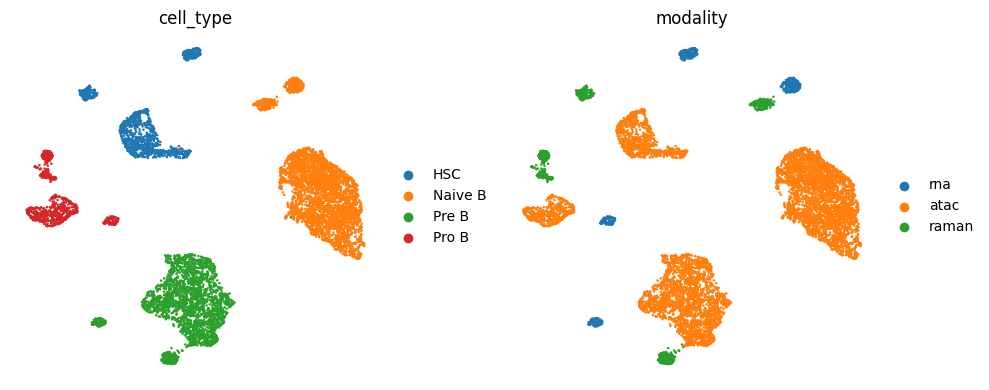

UMAP saved to: mmvae_out\umap_celltype_modality.png


g:\C_pan_copy_dir\.conda\envs\torch_gpu_env\Lib\site-packages\scanpy\tools\_utils.py:41: UserWarning: You’re trying to run this on 128 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


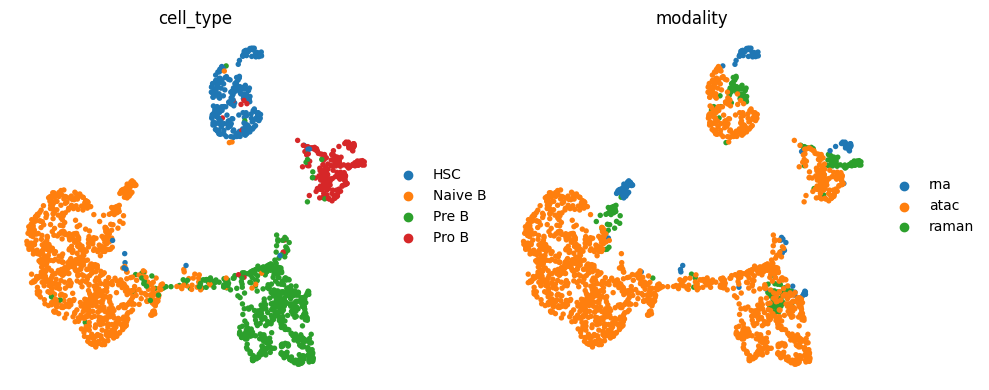

UMAP saved to: mmvae_out\umap_celltype_modality.png


In [56]:
idx2ct = {v:k for k,v in ct2idx.items()}  # ct2idx 见训练脚本

draw_umap_scanpy_nb(  # 只看训练集
    model, [tr_r, tr_n, tr_a], cfg, device, idx2ct
)
draw_umap_scanpy_nb(  # 看测试集
    model, [te_r, te_n, te_a], cfg, device, idx2ct
)


g:\C_pan_copy_dir\.conda\envs\torch_gpu_env\Lib\site-packages\scanpy\tools\_utils.py:41: UserWarning: You’re trying to run this on 64 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


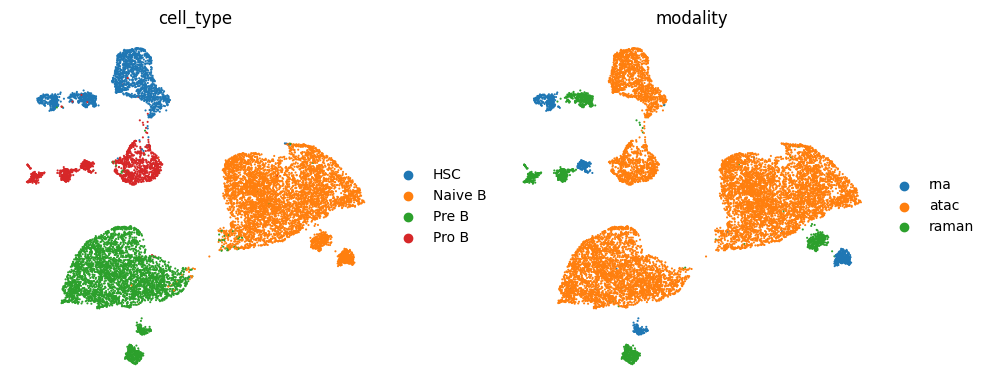

UMAP saved to: mmvae_out\umap_celltype_modality.png


In [ ]:
idx2ct = {v:k for k,v in ct2idx.items()}  # ct2idx 见训练脚本
draw_umap_scanpy_nb(
    model,
    [ds_r, ds_n, ds_a],      # 3 个 Dataset
    cfg, device,
    idx2ct=idx2ct,
    max_cells=None           # 如想抽样 2 万细胞，写 20000
)

g:\C_pan_copy_dir\.conda\envs\torch_gpu_env\Lib\site-packages\scanpy\tools\_utils.py:41: UserWarning: You’re trying to run this on 64 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


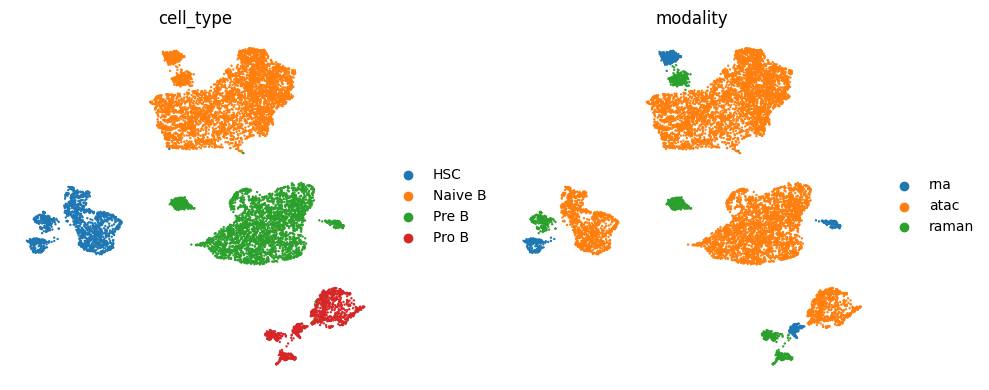

UMAP saved to: mmvae_out\umap_celltype_modality.png


In [47]:
# 1. 仍然复用 idx2ct
idx2ct = {v: k for k, v in ct2idx.items()}

# 2. 训练集：tr_r / tr_n / tr_a   （注意这 3 个变量是 Subset）
draw_umap_scanpy_nb(
    model,
    [tr_r, tr_n, tr_a],          # ← 换成 train 的三路 dataset / subset
    cfg, device,
    idx2ct=idx2ct,
    max_cells=None,              # 太大时可设 30000 做下采样
    dpi=300
)


In [48]:
from sklearn.neighbors import NearestNeighbors	
# 假设你已经有 ds_r / ds_n / ds_a 这 3 个 Dataset
from torch.utils.data import DataLoader
import torch, numpy as np

model.eval(); zs = []; mods = []; ys = []
with torch.no_grad():
    for ds, mod_name in [(ds_r, 'raman'),
                         (ds_n, 'rna'),
                         (ds_a, 'atac')]:
        loader = DataLoader(ds, batch_size=1024, shuffle=False)
        for x, y, _ in loader:
            mu, _ = model.enc[mod_name](x.to(device))
            zs.append(mu.cpu().numpy())
            ys.extend(y.numpy())
            mods.extend([mod_name]*len(y))

z_all = np.vstack(zs)          # (N, latent_dim)
y_all = np.array(ys)           # (N,)
mods  = np.array(mods)         # (N,)

z_r   = z_all[mods == 'raman']; y_r = y_all[mods == 'raman']
z_ref = z_all[mods != 'raman']; y_ref = y_all[mods != 'raman']

nbrs  = NearestNeighbors(n_neighbors=5).fit(z_ref)
idx   = nbrs.kneighbors(z_r, return_distance=False)
acc   = (y_ref[idx] == y_r[:, None]).mean()
print(f"Cross-modal kNN ACC (Raman → RNA+ATAC) = {acc:.3f}")


Cross-modal kNN ACC (Raman → RNA+ATAC) = 0.986


# 本次实验20250630
相关代码和chatgpt相关沟通请见如下链接：
https://chatgpt.com/share/6862a9b7-3f98-800f-90ce-bf405cf99dff

In [29]:
adata_a.obs.cell_type_refined.unique()

['Naive B', 'pro B', 'pre B', 'HSC']
Categories (4, object): ['HSC', 'Naive B', 'pre B', 'pro B']

In [30]:
adata_a.obs.cell_type.unique()

['Naive CD20+ B', 'B1 B', 'Lymph prog', 'Transitional B', 'G/M prog', ..., 'cDC2', 'CD4+ T activated', 'CD8+ T naive', 'NK', 'CD16+ Mono']
Length: 20
Categories (20, object): ['B1 B', 'CD4+ T activated', 'CD4+ T naive', 'CD8+ T', ..., 'Proerythroblast', 'Transitional B', 'cDC2', 'pDC']

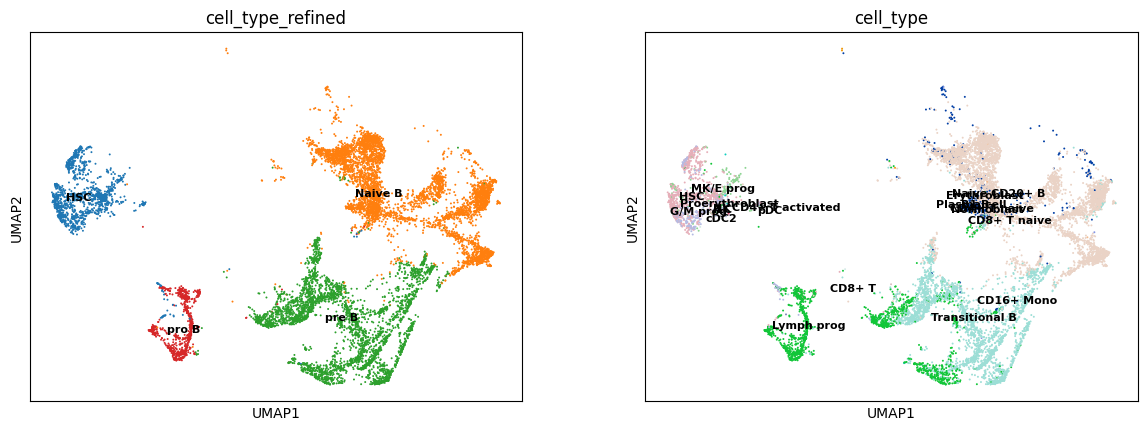

In [32]:
sc.pl.umap(adata_a, color=["cell_type_refined","cell_type"], size=8, legend_loc="on data", legend_fontsize=8)

In [33]:
# adata_a 为你的 AnnData
adata_a.obs.rename(
    columns={
        "cell_type": "dataset_original_cell_type",     # 先保留原列
        "cell_type_refined": "cell_type"               # 再把 refined 列接管名称
    },
    inplace=True
)


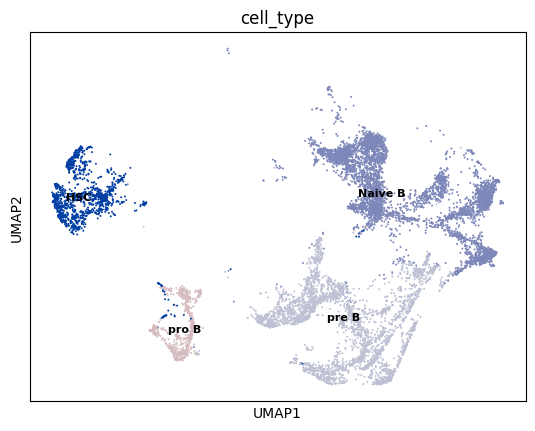

In [34]:
sc.pl.umap(adata_a, color=["cell_type"], size=8, legend_loc="on data", legend_fontsize=8)

In [ ]:
"""
Multi‑modal VAE (MMVAE) — *cross‑modality enabled* version
=========================================================

改动概览
────────
1. **fc_block → GroupNorm + LayerNorm** 以替换 BatchNorm，解决小 batch + 稀疏矩阵不稳定问题。
2. **NBDecoder + NB log‑likelihood**：RNA/ATAC 采用 μ/θ 参数化的 Negative Binomial 输出与重构损失。
3. **Cross Reconstruction & Cycle Consistency**
   • 在 *同一 cell‑type* 内对不同模态做 cross recon  
   • 简易 cycle：`Enc_mod1(x) → z → Dec_mod2(z) → Enc_mod2(·) → z'`，最小化 ‖z−z'‖²
4. **Config 新增 λ_cycle 与 λ_cross 权重，KL 调度改为 β‑VAE free‑bits。
5. **稀疏友好**：可选 `sc.pp.log1p` 而非 `scale()`；ATAC 稀疏矩阵保持 COO，不再 densify。

所有改动处以 **★★★** 标记。
"""

import scanpy as sc
import anndata as ad
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from itertools import cycle
from pathlib import Path
import random

# ============ 1. Dataset ============
class AnnDataset(Dataset):
    def __init__(self, adata: ad.AnnData, modality: str, ct2idx: dict):
        x = adata.X
        self.X = x.toarray().astype(np.float32) if hasattr(x, 'toarray') else x.astype(np.float32)
        self.y = adata.obs["cell_type"].map(ct2idx).values.astype(np.int64)
        self.mod = np.full(len(self.y), modality)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i], self.mod[i]

# ============ 2. Helper blocks ============

# ★★★ BatchNorm → GroupNorm, 支持稀疏 + 小 batch
class fc_block(nn.Module):
    def __init__(self, in_dim, out_dim, p_drop=0.2, groups=8):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.GroupNorm(groups, out_dim),  # 取代 BN
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop)
        )

    def forward(self, x):
        return self.block(x)

# ============ 3. Encoders & Decoders ============

class Encoder(nn.Module):
    def __init__(self, in_dim, latent_dim, hidden=(1024, 512, 256)):
        super().__init__()
        layers = []
        dims = [in_dim] + list(hidden)
        for i in range(len(dims) - 1):
            layers.append(fc_block(dims[i], dims[i + 1]))
        self.shared = nn.Sequential(*layers)
        self.mu     = nn.Linear(hidden[-1], latent_dim)
        self.logvar = nn.Linear(hidden[-1], latent_dim)

    def forward(self, x):
        h = self.shared(x)
        return self.mu(h), self.logvar(h)

# ---------- Gaussian Decoder ----------
class GaussianDecoder(nn.Module):
    def __init__(self, out_dim, latent_dim, hidden=(256, 512, 1024)):
        super().__init__()
        dims = [latent_dim] + list(hidden)
        layers = [fc_block(dims[i], dims[i + 1]) for i in range(len(dims) - 1)]
        self.net = nn.Sequential(*layers)
        self.out = nn.Linear(hidden[-1], out_dim)

    def forward(self, z):
        return self.out(self.net(z))

# ---------- ★★★ NB Decoder ----------
class NBDecoder(nn.Module):
    """输出 (mu, theta) 以 Parameterisation 方式构造 NB 分布"""
    def __init__(self, out_dim, latent_dim, hidden=(256, 512, 1024)):
        super().__init__()
        dims = [latent_dim] + list(hidden)
        layers = [fc_block(dims[i], dims[i + 1]) for i in range(len(dims) - 1)]
        self.net = nn.Sequential(*layers)
        self.mu_layer    = nn.Linear(hidden[-1], out_dim)
        self.theta_layer = nn.Linear(hidden[-1], out_dim)

    def forward(self, z):
        h = self.net(z)
        mu    = F.softplus(self.mu_layer(h)) + 1e-4
        theta = F.softplus(self.theta_layer(h)) + 1e-4
        return mu, theta

# ============ 4. MMVAE Core ============
class MMVAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.latent = cfg['latent']
        self.enc = nn.ModuleDict()
        self.dec = nn.ModuleDict()

        for m, (dim, otype) in cfg['mods'].items():
            self.enc[m] = Encoder(dim, self.latent)
            if otype == 'gauss':
                self.dec[m] = GaussianDecoder(dim, self.latent)
            elif otype == 'nb':
                self.dec[m] = NBDecoder(dim, self.latent)
            else:
                raise ValueError(f"Unknown output_type {otype}")

        # 分类器 + center
        self.classifier = nn.Sequential(
            nn.Linear(self.latent, 128), nn.ReLU(),
            nn.Linear(128, cfg['n_cls'])
        )
        self.centers = nn.Parameter(torch.randn(cfg['n_cls'], self.latent))

    # ---------- utils ----------
    @staticmethod
    def reparam(mu, logv):
        std = torch.exp(0.5 * logv)
        return mu + std * torch.randn_like(std)

    # ---------- forward ----------
    def forward(self, x, mod):
        mu, lv = self.enc[mod](x)
        z = self.reparam(mu, lv)
        out = self.dec[mod](z)
        logits = self.classifier(z)
        return out, mu, lv, logits, z

    # ---------- Losses ----------
    def _recon_loss(self, x, out, mod):
        otype = self.cfg['mods'][mod][1]
        if otype == 'gauss':
            return F.mse_loss(out, x, reduction='mean')
        elif otype == 'nb':
            mu, theta = out
            # NB log‑likelihood (总 count = theta, logits = logit(p))
            dist = torch.distributions.NegativeBinomial(total_count=theta, logits=(mu + 1e-8).log())
            return -dist.log_prob(x).mean()
        else:
            raise ValueError

    def loss(self, x_a, out_a, mu_a, lv_a, logits_a, y_a, z_a,
             mod_a, x_b=None, z_cycle=None, kl_coef=1.0):

        cfg = self.cfg
        recon = self._recon_loss(x_a, out_a, mod_a)
        kl = -0.5 * torch.mean(1 + lv_a - mu_a.pow(2) - lv_a.exp())
        ce = F.cross_entropy(logits_a, y_a)
        acc = (logits_a.argmax(1) == y_a).float().mean()
        center = (z_a - self.centers[y_a]).pow(2).sum(1).mean()

        # ★★★ cross & cycle
        cross = torch.tensor(0.0, device=x_a.device)
        cycle = torch.tensor(0.0, device=x_a.device)
        if x_b is not None:
            cross = self._recon_loss(x_b[0], x_b[1], x_b[2])
        if z_cycle is not None:
            cycle = F.mse_loss(z_cycle, z_a.detach())

        loss = (cfg['λ_r'] * recon +
                kl_coef * kl +
                cfg['λ_ce'] * ce +
                cfg['λ_cen'] * center +
                cfg['λ_cross'] * cross +
                cfg['λ_cycle'] * cycle)

        return loss, dict(recon=recon.item(), kl=kl.item(), ce=ce.item(), acc=acc.item(),
                          cross=cross.item(), cycle=cycle.item())

# ============ 5. Training Loop ============

def split_dataset_three(ds, train_ratio=0.7, val_ratio=0.15):
    n = len(ds)
    n_train, n_val = int(train_ratio * n), int(val_ratio * n)
    n_test = n - n_train - n_val
    return random_split(ds, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(0))

def train(model, loaders, cfg, device):
    opt = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    best, patience = 1e9, 0
    cycles = {m: cycle(l) for m, l in loaders['train'].items()}

    free_bits = 0.05  # ★★★ free‑bits trick

    for epoch in range(cfg['ep']):
        model.train()
        meters = {k: 0.0 for k in ['recon', 'kl', 'ce', 'acc', 'cross', 'cycle', 'count']}

        for _ in range(cfg['steps_per_epoch']):
            mods = random.sample(list(cycles.keys()), k=len(cycles))
            for mod_a in mods:
                # 1) 主模态 batch
                x_a, y_a, _ = next(cycles[mod_a])
                x_a, y_a = x_a.to(device), y_a.to(device)
                out_a, mu_a, lv_a, logits_a, z_a = model(x_a, mod_a)

                # 2) ★★★ 取同一 cell‑type 的另一随机模态做 cross
                mod_b_choices = [m for m in mods if m != mod_a]
                mod_b = random.choice(mod_b_choices)
                x_b_full, y_b_full, _ = next(cycles[mod_b])
                mask = (y_b_full == y_a[0])  # 简易同类 cell‑type 匹配
                if mask.sum() == 0:
                    x_b, y_b = None, None
                    cross_tuple, z_cycle = None, None
                else:
                    x_b = x_b_full[mask][:len(x_a)].to(device)  # 尽量等长
                    out_cross = model.dec[mod_b](z_a.detach())
                    cross_tuple = (x_b, out_cross, mod_b)
                    # cycle: 再 encode
                    mu_c, _ = model.enc[mod_b](out_cross.detach())
                    z_cycle = mu_c

                # 3) KL 系数 β schedule
                kl_coef = min(1.0, (epoch + 1) / cfg['kl_warm'])
                loss, stats = model.loss(x_a, out_a, mu_a, lv_a, logits_a, y_a,
                                          z_a, mod_a,
                                          x_b=cross_tuple, z_cycle=z_cycle,
                                          kl_coef=max(kl_coef, free_bits))

                opt.zero_grad(); loss.backward(); opt.step()

                for k in ['recon', 'kl', 'ce', 'acc', 'cross', 'cycle']:
                    meters[k] += stats[k] * len(y_a)
                meters['count'] += len(y_a)

        for k in meters:
            if k != 'count': meters[k] /= meters['count']

        print(f"E{epoch:03d} loss={(meters['recon']+meters['kl']+meters['ce']):.4f} "
              f"acc={meters['acc']:.3f} cross={meters['cross']:.4f} cycle={meters['cycle']:.4f}")

        # ------------ validation  ------------
        model.eval(); val_loss, nval = 0.0, 0
        with torch.no_grad():
            for mod, v_loader in loaders['val'].items():
                for x, y, _ in v_loader:
                    x, y = x.to(device), y.to(device)
                    out, mu, lv, logits, z = model(x, mod)
                    l, _ = model.loss(x, out, mu, lv, logits, y, z, mod, kl_coef=1.0)
                    val_loss += l.item() * len(y); nval += len(y)
        val_loss /= nval
        if val_loss < best - 1e-3:
            best, patience = val_loss, 0
            torch.save(model.state_dict(), cfg['outdir'] / "best.pt")
        else:
            patience += 1
            if patience >= cfg['es']:
                print("Early stopping"); break

# ============ 6. Usage Example (略) ============
# 与原脚本类似，构造 AnnDataset、DataLoader、cfg 后：
# model = MMVAE(cfg).to(device)
# train(model, loaders, cfg, device)


In [ ]:
# MMVAE: 添加 latent disentanglement + Raman → RNA cross-reconstruction
# ========================== 修改概要 ===========================
# 1. ★★★ EncoderSplit: 输出分解的 latent (shared + specific)
# 2. ★★★ MMVAE_Disentangle: forward() 中输出 z_shared, z_spec 
# 3. ★★★ loss(): 新增 orthogonal loss + Raman → RNA cross-reconstruction
# ==========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------- ★★★ 1. Encoder with latent split -------------
class EncoderSplit(nn.Module):
    def __init__(self, in_dim, latent_shared, latent_spec, hidden=(1024, 512, 256)):
        super().__init__()
        self.shared_net = nn.Sequential(*[fc_block(in_dim if i == 0 else hidden[i - 1], h)
                                          for i, h in enumerate(hidden)])
        self.mu_shared = nn.Linear(hidden[-1], latent_shared)
        self.logvar_shared = nn.Linear(hidden[-1], latent_shared)
        self.mu_spec = nn.Linear(hidden[-1], latent_spec)
        self.logvar_spec = nn.Linear(hidden[-1], latent_spec)

    def forward(self, x):
        h = self.shared_net(x)
        return self.mu_shared(h), self.logvar_shared(h), self.mu_spec(h), self.logvar_spec(h)

# ----------- ★★★ 2. Disentangled MMVAE model -------------
class MMVAE_Disentangle(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.latent_shared = cfg['latent_shared']
        self.latent_spec = cfg['latent_spec']

        self.enc = nn.ModuleDict()
        self.dec = nn.ModuleDict()

        for m, (dim, otype) in cfg['mods'].items():
            self.enc[m] = EncoderSplit(dim, self.latent_shared, self.latent_spec)
            decoder_in = self.latent_shared + self.latent_spec
            if otype == 'gauss':
                self.dec[m] = GaussianDecoder(dim, decoder_in)
            elif otype == 'nb':
                self.dec[m] = NBDecoder(dim, decoder_in)

        self.classifier = nn.Sequential(
            nn.Linear(self.latent_shared, 128), nn.ReLU(),
            nn.Linear(128, cfg['n_cls'])
        )
        self.centers = nn.Parameter(torch.randn(cfg['n_cls'], self.latent_shared))

    def reparam(self, mu, logv):
        std = torch.exp(0.5 * logv)
        return mu + std * torch.randn_like(std)

    def forward(self, x, mod):
        mu_s, lv_s, mu_p, lv_p = self.enc[mod](x)
        z_s = self.reparam(mu_s, lv_s)
        z_p = self.reparam(mu_p, lv_p)
        z = torch.cat([z_s, z_p], dim=-1)

        out = self.dec[mod](z)
        logits = self.classifier(z_s)
        return out, mu_s, lv_s, mu_p, lv_p, logits, z_s, z_p

    def loss(self, x, out, mu_s, lv_s, mu_p, lv_p, logits, y, z_s, z_p,
             mod, x_cross=None, out_cross=None, mod_cross=None, kl_coef=1.0):

        recon = self._recon_loss(x, out, mod)
        kl_s = -0.5 * torch.mean(1 + lv_s - mu_s.pow(2) - lv_s.exp())
        kl_p = -0.5 * torch.mean(1 + lv_p - mu_p.pow(2) - lv_p.exp())
        kl = kl_s + kl_p

        ce = F.cross_entropy(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        center = (z_s - self.centers[y]).pow(2).sum(1).mean()

        # ★★★ orthogonal loss between z_s and z_p
        orthogonal = torch.sum((F.normalize(z_s, dim=-1) * F.normalize(z_p, dim=-1))**2)

        # ★★★ Raman → RNA cross-reconstruction loss
        cross = torch.tensor(0.0, device=x.device)
        if x_cross is not None and out_cross is not None:
            cross = self._recon_loss(x_cross, out_cross, mod_cross)

        loss = (self.cfg['λ_r'] * recon +
                kl_coef * kl +
                self.cfg['λ_ce'] * ce +
                self.cfg['λ_cen'] * center +
                self.cfg.get('λ_dis', 0.01) * orthogonal +
                self.cfg.get('λ_cross', 0.2) * cross)

        return loss, dict(recon=recon.item(), kl=kl.item(), ce=ce.item(),
                          acc=acc.item(), orthogonal=orthogonal.item(), cross=cross.item())

    def _recon_loss(self, x, out, mod):
        otype = self.cfg['mods'][mod][1]
        if otype == 'gauss':
            return F.mse_loss(out, x, reduction='mean')
        elif otype == 'nb':
            mu, theta = out
            dist = torch.distributions.NegativeBinomial(total_count=theta, logits=(mu + 1e-8).log())
            return -dist.log_prob(x).mean()
        else:
            raise ValueError
